# 💰 Sales Data Analysis — Fast Food Chain (Nov–Dec 2022)
**Dataset:** `SalesData.xlsx` — 254 sales transactions across 5 European cities  
**Goal:** Clean messy data, engineer Revenue column, and answer 10 real business questions  
**Tools:** Pandas · Matplotlib · Seaborn

> **Commands used in this project:**  
> `reset_index()` · `loc[]` · `info()` · `drop()` · `str.strip().str.replace()` · `duplicated()` · `drop_duplicates()` · `round()` · `pd.to_datetime()` · `groupby()` · `std()` · `var()` · `mean()` · `agg()` · `head()` · `columns` · `unique()` · `nunique()` · `describe()` · `astype()` · `dtype` · `value_counts()` · `plot(kind='bar')` · `type()` · `sort_values()` · `dt.month`


## 1. Imports

In [6]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [7]:
# Load the Excel file — header is on row 1 (index 1), not row 0
# Drop the first unnamed index column that Excel added
data = pd.read_excel('SalesData.xlsx', header=1)
data = data.drop(columns=[data.columns[0]])

## 3. First Look at the Data

In [8]:
# First 5 rows
data.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin


In [9]:
# Shape — rows and columns
print("Shape:", data.shape)

Shape: (254, 9)


In [10]:
# All column names
print("Columns:", data.columns.tolist())

Columns: ['Order ID', 'Date', 'Product', 'Price', 'Quantity', 'Purchase Type', 'Payment Method', 'Manager', 'City']


In [11]:
# Data type of each column
print(data.dtypes)

Order ID                   int64
Date              datetime64[us]
Product                      str
Price                    float64
Quantity                 float64
Purchase Type                str
Payment Method               str
Manager                      str
City                         str
dtype: object


In [12]:
# Full info at once
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        254 non-null    int64         
 1   Date            254 non-null    datetime64[us]
 2   Product         254 non-null    str           
 3   Price           254 non-null    float64       
 4   Quantity        254 non-null    float64       
 5   Purchase Type   254 non-null    str           
 6   Payment Method  254 non-null    str           
 7   Manager         254 non-null    str           
 8   City            254 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(5)
memory usage: 18.0 KB


In [13]:
# Descriptive statistics
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Order ID,254.0,10584.133858,10452.0,10520.25,10583.5,10649.75,10713.0,75.889181
Date,254,2022-12-03 10:23:37.322834,2022-11-07 00:00:00,2022-11-21 00:00:00,2022-12-03 00:00:00,2022-12-16 18:00:00,2022-12-29 00:00:00,NaN
Price,254.0,7.102323,2.95,3.49,4.99,9.95,29.05,4.341855
Quantity,254.0,460.610541,200.400802,201.005025,538.876059,677.444188,754.426482,214.889551


---
## 🔧 Data Cleaning
---

### Step 1 — Check & Remove Duplicate Records


In [14]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


In [15]:
# Drop duplicates if any
data.drop_duplicates(inplace=True)
print("Shape after drop_duplicates:", data.shape)

Shape after drop_duplicates: (254, 9)


### Step 2 — Check Missing Values


In [16]:
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Order ID          0
Date              0
Product           0
Price             0
Quantity          0
Purchase Type     0
Payment Method    0
Manager           0
City              0
dtype: int64


### Step 3 — Fix Manager Column (Extra Spaces)

> ⚠️ **This is the main data quality issue in this dataset.**  
> The `Manager` column has inconsistent spacing:  
> `'Tom      Jackson'`, `'       Pablo Perez'`, `'Remy    Monet'` — all refer to the same person.  
>  
> Without fixing this, `groupby('Manager')` would treat them as **14 different managers** instead of 5.  
> `str.strip()` removes leading/trailing spaces.  
> `str.replace(r'\s+', ' ', regex=True)` collapses multiple spaces between words into one.


In [17]:
# Before cleaning — show all "unique" manager values (should be 5, but shows 14)
print("Manager values BEFORE cleaning:")
print(data['Manager'].unique())
print(f"\nUnique count before: {data['Manager'].nunique()}")

Manager values BEFORE cleaning:
<StringArray>
[  'Tom      Jackson', '       Pablo Perez',      'Joao    Silva',
      'Walter Muller',      'Remy    Monet',         'Remy Monet',
  '       Remy Monet',     'Remy     Monet',        'Pablo Perez',
      'Pablo   Perez',       'Pablo  Perez',     'Pablo    Perez',
         'Joao Silva',        'Tom Jackson']
Length: 14, dtype: str

Unique count before: 14


In [ ]:
# Fix: strip leading/trailing spaces, then collapse internal multiple spaces
data['Manager'] = data['Manager'].str.strip().str.replace(r'\s+', ' ', regex=True)

print("Manager values AFTER cleaning:")
print(data['Manager'].unique())
print(f"\nUnique count after: {data['Manager'].nunique()}")

Manager values AFTER cleaning:
<StringArray>
['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller', 'Remy Monet']
Length: 5, dtype: str

Unique count after: 5


In [ ]:
# Also fix Payment Method — has leading spaces
print("Payment Method before:", data['Payment Method'].unique())
data['Payment Method'] = data['Payment Method'].str.strip()
print("Payment Method after: ", data['Payment Method'].unique())

Payment Method before: <StringArray>
[' Gift Card', ' Credit Card', ' Cash']
Length: 3, dtype: str
Payment Method after:  <StringArray>
['Gift Card', 'Credit Card', 'Cash']
Length: 3, dtype: str


### Step 4 — Create Revenue Column

> **Revenue = Price × Quantity**  
> This derived column is the foundation of most analytical questions in this project.


In [ ]:
# Create Revenue column and round to 2 decimal places
data['Revenue'] = (data['Price'] * data['Quantity']).round(2)

print("Revenue column created:")
data[['Product', 'Price', 'Quantity', 'Revenue']].head()

Revenue column created:


,Product,Price,Quantity,Revenue
0,Fries,3.49,573.065903,2000.0
1,Beverages,2.95,745.762712,2200.0
2,Sides & Other,4.99,200.400802,1000.0
3,Burgers,12.99,569.668976,7400.0
4,Chicken Sandwiches,9.95,201.005025,2000.0


### Step 5 — Extract Month from Date

> We use `dt.month` to extract the month number from the datetime column.  
> This enables monthly filtering and aggregation (Q6, Q9).


In [ ]:
# Date column is already datetime — extract month number
data['Month'] = data['Date'].dt.month

print("Month column added:")
print(data['Month'].value_counts().sort_index())
print()
print("Month 11 = November, Month 12 = December")

Month column added:
Month
11    113
12    141
Name: count, dtype: int64

Month 11 = November, Month 12 = December


---
## 📋 Analytical Questions
---

### Q1 — Most Preferred Payment Method


In [ ]:
# value_counts() shows each payment method ranked by frequency
payment_counts = data['Payment Method'].value_counts()
print(payment_counts)
print(f"\nMost preferred: {payment_counts.idxmax()} ({payment_counts.max()} transactions)")

Payment Method
Credit Card    120
Cash            76
Gift Card       58
Name: count, dtype: int64

Most preferred: Credit Card (120 transactions)


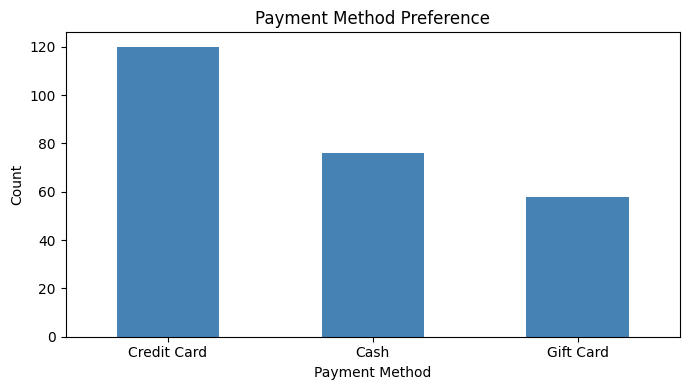

In [ ]:
# Bar chart
payment_counts.plot(kind='bar', color='steelblue', figsize=(7, 4))
plt.title("Payment Method Preference")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q2 — Most Selling Product (By Quantity & By Revenue)


In [ ]:
# By Quantity — which product sold the most units?
qty_by_product = data.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
print("Most Selling by Quantity:")
print(qty_by_product)
print(f"\nTop product by Quantity: {qty_by_product.idxmax()}")

Most Selling by Quantity:
Product
Beverages             34983.050847
Fries                 32034.383954
Burgers               29022.324865
Chicken Sandwiches    11135.678392
Sides & Other          9819.639279
Name: Quantity, dtype: float64

Top product by Quantity: Beverages


In [ ]:
# By Revenue — which product generated the most money?
rev_by_product = data.groupby('Product')['Revenue'].sum().round(2).sort_values(ascending=False)
print("Most Selling by Revenue:")
print(rev_by_product)
print(f"\nTop product by Revenue: {rev_by_product.idxmax()}")

Most Selling by Revenue:
Product
Burgers               377000.0
Fries                 125674.5
Chicken Sandwiches    114639.2
Beverages             103200.0
Sides & Other          49000.0
Name: Revenue, dtype: float64

Top product by Revenue: Burgers


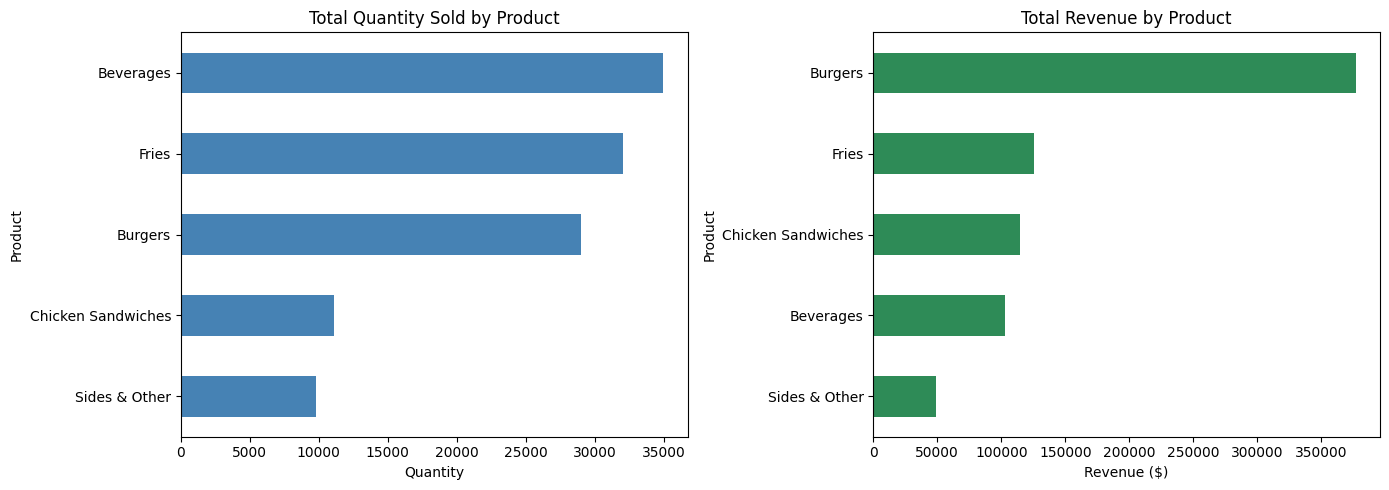

In [ ]:
# Side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qty_by_product.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Total Quantity Sold by Product")
axes[0].set_xlabel("Quantity")

rev_by_product.sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title("Total Revenue by Product")
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.show()

### Q3 — City with Maximum Revenue / Manager with Maximum Revenue


In [ ]:
# Revenue by City
rev_by_city = data.groupby('City')['Revenue'].sum().round(2).sort_values(ascending=False)
print("Revenue by City:")
print(rev_by_city)
print(f"\nCity with MAX Revenue: {rev_by_city.idxmax()} (${rev_by_city.max():,.2f})")

Revenue by City:
City
Lisbon    241713.7
London    211200.0
Madrid    136200.0
Berlin    100600.0
Paris      79800.0
Name: Revenue, dtype: float64

City with MAX Revenue: Lisbon ($241,713.70)


In [ ]:
# Revenue by Manager — after cleaning the Manager column
rev_by_manager = data.groupby('Manager')['Revenue'].sum().round(2).sort_values(ascending=False)
print("\nRevenue by Manager:")
print(rev_by_manager)
print(f"\nManager with MAX Revenue: {rev_by_manager.idxmax()} (${rev_by_manager.max():,.2f})")


Revenue by Manager:
Manager
Joao Silva       241713.7
Tom Jackson      211200.0
Pablo Perez      136200.0
Walter Muller    100600.0
Remy Monet        79800.0
Name: Revenue, dtype: float64

Manager with MAX Revenue: Joao Silva ($241,713.70)


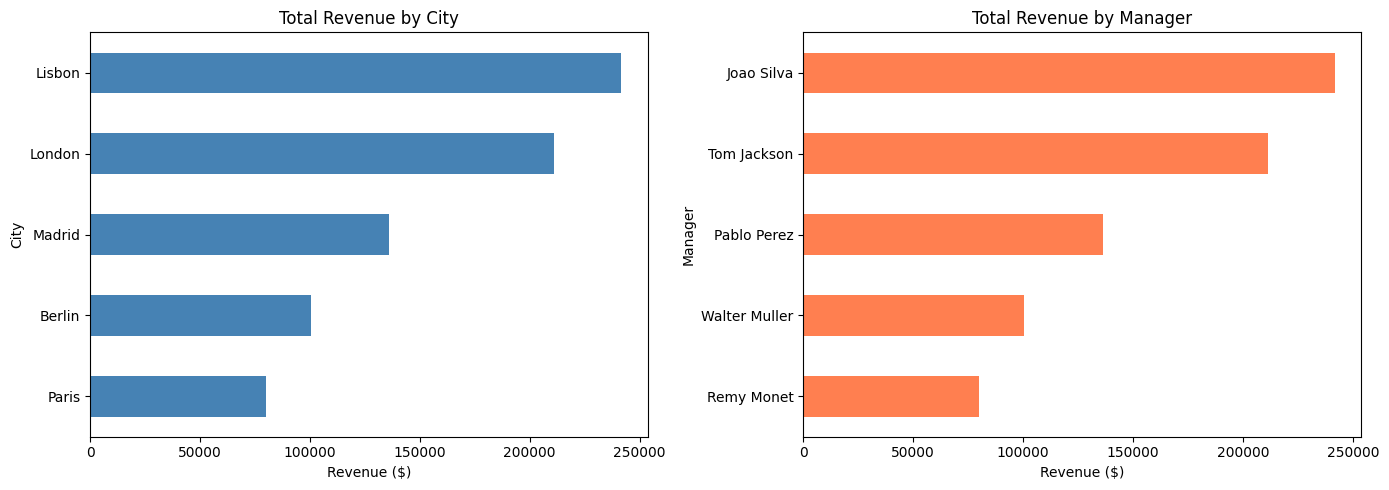

In [ ]:
# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev_by_city.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Total Revenue by City")
axes[0].set_xlabel("Revenue ($)")

rev_by_manager.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title("Total Revenue by Manager")
axes[1].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.show()

### Q4 — Date-wise Revenue


In [ ]:
# Group by Date and sum Revenue
daily_revenue = data.groupby('Date')['Revenue'].sum().round(2)
print("Date-wise Revenue (first 10 days):")
print(daily_revenue.head(10))

Date-wise Revenue (first 10 days):
Date
2022-11-07     5200.0
2022-11-08    12400.0
2022-11-09    14200.0
2022-11-10    13200.0
2022-11-11    14400.0
2022-11-12    14000.0
2022-11-13    27674.5
2022-11-14    17839.2
2022-11-15    13600.0
2022-11-16    13600.0
Name: Revenue, dtype: float64


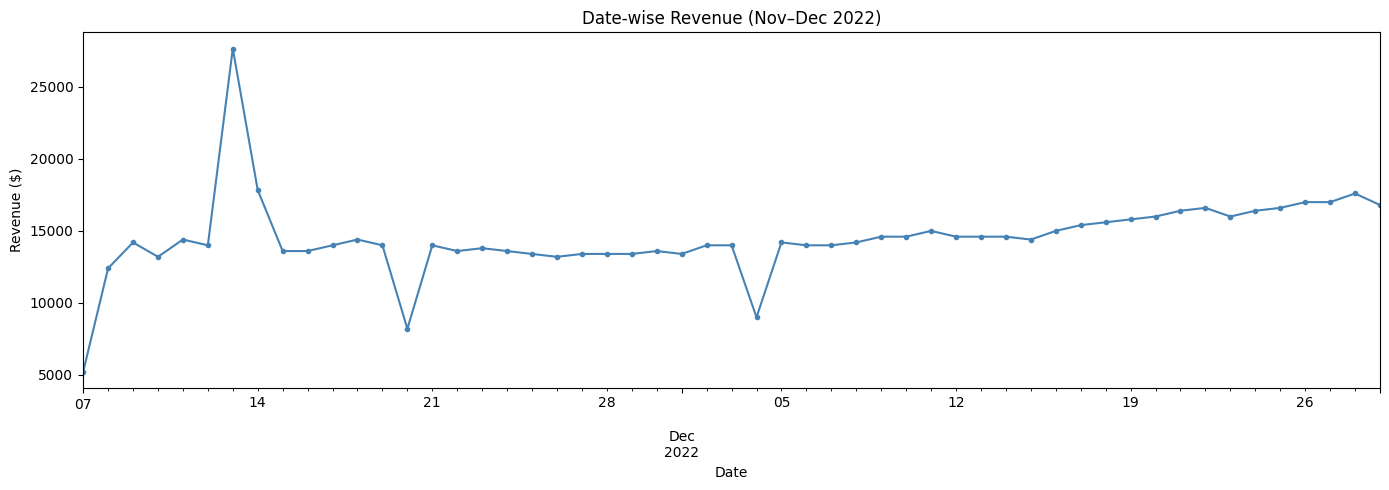

In [ ]:
# Line chart for date-wise revenue trend
plt.figure(figsize=(14, 5))
daily_revenue.plot(kind='line', color='steelblue', marker='o', markersize=3)
plt.title("Date-wise Revenue (Nov–Dec 2022)")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

### Q5 — Average Revenue


In [ ]:
# Overall average revenue per transaction
avg_revenue = data['Revenue'].mean().round(2)
print(f"Average Revenue per transaction: ${avg_revenue:,.2f}")
print(f"Median Revenue: ${data['Revenue'].median():,.2f}")

Average Revenue per transaction: $3,029.58
Median Revenue: $2,100.00


### Q6 — Average Revenue of November & December


In [ ]:
# Filter November (month=11) and December (month=12) separately
nov = data[data['Month'] == 11]
dec = data[data['Month'] == 12]

print(f"November — Avg Revenue: ${nov['Revenue'].mean().round(2):,.2f} ({len(nov)} transactions)")
print(f"December — Avg Revenue: ${dec['Revenue'].mean().round(2):,.2f} ({len(dec)} transactions)")

November — Avg Revenue: $2,939.06 (113 transactions)
December — Avg Revenue: $3,102.13 (141 transactions)


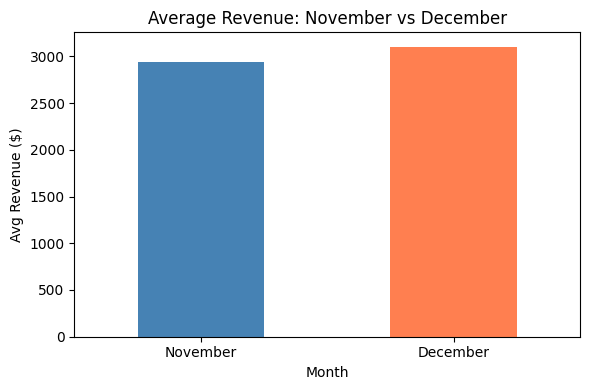

In [ ]:
# Compare monthly averages visually
monthly_avg = data.groupby('Month')['Revenue'].mean().round(2)
monthly_avg.index = ['November', 'December']

monthly_avg.plot(kind='bar', color=['steelblue', 'coral'], figsize=(6, 4))
plt.title("Average Revenue: November vs December")
plt.xlabel("Month")
plt.ylabel("Avg Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Q7 — Standard Deviation of Revenue and Quantity


In [ ]:
# std() measures how spread out the values are around the mean
print("Standard Deviation:")
print(f"  Revenue  : ${data['Revenue'].std().round(2):,.2f}")
print(f"  Quantity : {data['Quantity'].std().round(2)}")
print()
# Also by product
print("Std Dev of Revenue per Product:")
print(data.groupby('Product')['Revenue'].std().round(2).sort_values(ascending=False))

Standard Deviation:
  Revenue  : $2,420.12
  Quantity : 214.89

Std Dev of Revenue per Product:
Product
Fries                 1947.21
Burgers                978.09
Chicken Sandwiches     571.25
Beverages               94.24
Sides & Other            0.00
Name: Revenue, dtype: float64


### Q8 — Variance of Revenue and Quantity

> 💡 **Variance vs Standard Deviation:**  
> Variance = std²  
> Both measure spread — but Variance is in squared units, making it harder to interpret directly.  
> Standard deviation is more intuitive because it's in the same unit as the data.


In [ ]:
print("Variance:")
print(f"  Revenue  : ${data['Revenue'].var().round(2):,.2f}")
print(f"  Quantity : {data['Quantity'].var().round(2)}"

Variance:
  Revenue  : $5,857,001.35
  Quantity : 46177.52


### Q9 — Was Revenue Increasing or Decreasing Over Time?


In [ ]:
# Weekly revenue to smooth out daily noise
data_indexed = data.set_index('Date')
weekly_revenue = data_indexed['Revenue'].resample('W').sum().round(2)

print("Weekly Revenue:")
print(weekly_revenue)

Weekly Revenue:
Date
2022-11-13    101074.5
2022-11-20     95639.2
2022-11-27     95000.0
2022-12-04     90800.0
2022-12-11    100600.0
2022-12-18    104200.0
2022-12-25    113800.0
2023-01-01     68400.0
Freq: W-SUN, Name: Revenue, dtype: float64


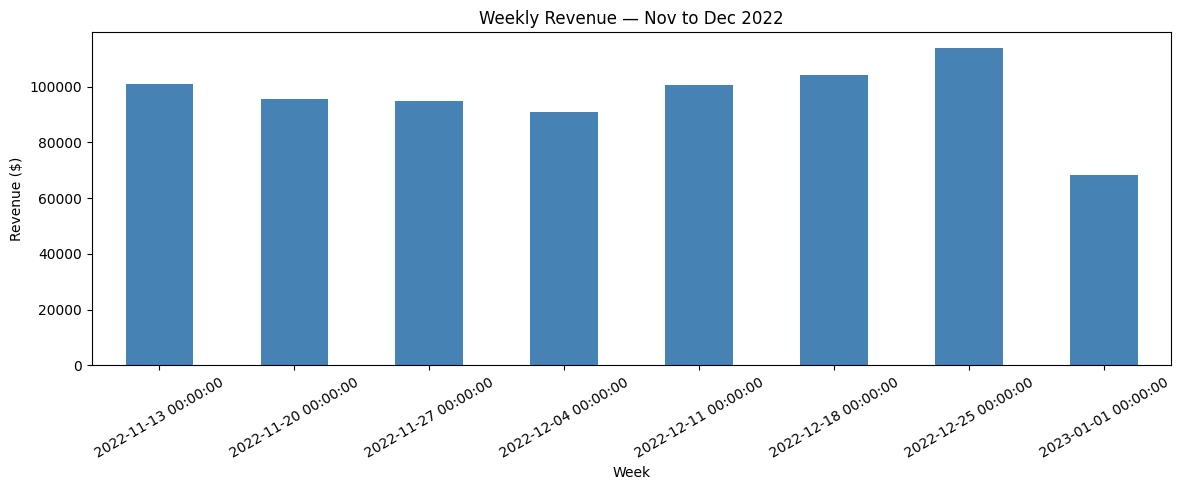

In [ ]:
# Plot the trend
plt.figure(figsize=(12, 5))
weekly_revenue.plot(kind='bar', color='steelblue')
plt.title("Weekly Revenue — Nov to Dec 2022")
plt.xlabel("Week")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# Monthly comparison
monthly_total = data.groupby('Month')['Revenue'].sum().round(2)
monthly_total.index = ['November', 'December']
print("Monthly Revenue:")
print(monthly_total)

diff = monthly_total['December'] - monthly_total['November']
direction = "INCREASED" if diff > 0 else "DECREASED"
print(f"\nRevenue {direction} from November to December by ${abs(diff):,.2f}")

Monthly Revenue:
November    332113.7
December    437400.0
Name: Revenue, dtype: float64

Revenue INCREASED from November to December by $105,286.30


### Q10 — Average Quantity Sold & Average Revenue for Each Product

> **Task:** Use `groupby()` with `agg()` to get multiple statistics in a single call.


In [ ]:
# agg() lets you apply multiple functions at once to multiple columns
product_stats = data.groupby('Product').agg(
    Avg_Quantity=('Quantity', 'mean'),
    Avg_Revenue =('Revenue',  'mean')
).round(2).sort_values('Avg_Revenue', ascending=False)

print("Average Quantity & Revenue per Product:")
product_stats

Average Quantity & Revenue per Product:


,Avg_Quantity,Avg_Revenue
Product,,
Burgers,558.12,7250.00
Fries,628.13,2464.21
Chicken Sandwiches,214.15,2204.60
Beverages,699.66,2064.00
Sides & Other,200.40,1000.00


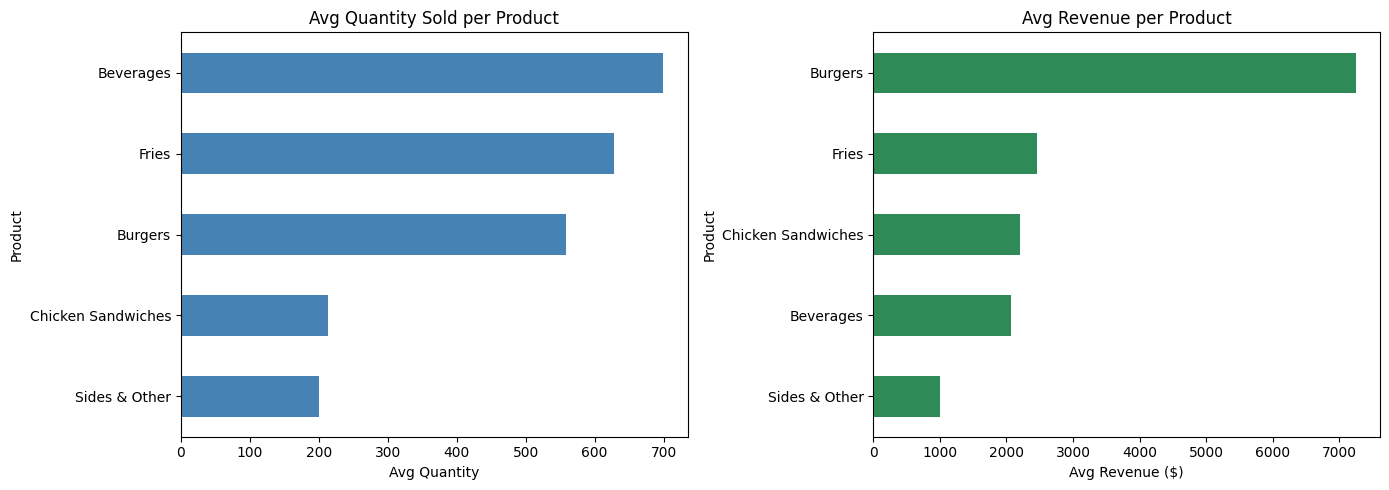

In [ ]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

product_stats['Avg_Quantity'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Avg Quantity Sold per Product")
axes[0].set_xlabel("Avg Quantity")

product_stats['Avg_Revenue'].sort_values().plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title("Avg Revenue per Product")
axes[1].set_xlabel("Avg Revenue ($)")

plt.tight_layout()
plt.show()

## 7. Additional Visualizations

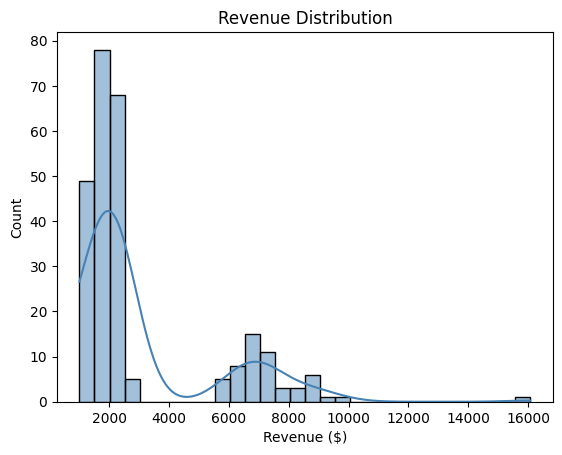

In [ ]:
# Revenue distribution
sns.histplot(data['Revenue'], kde=True, bins=30, color='steelblue')
plt.title("Revenue Distribution")
plt.xlabel("Revenue ($)")
plt.show()

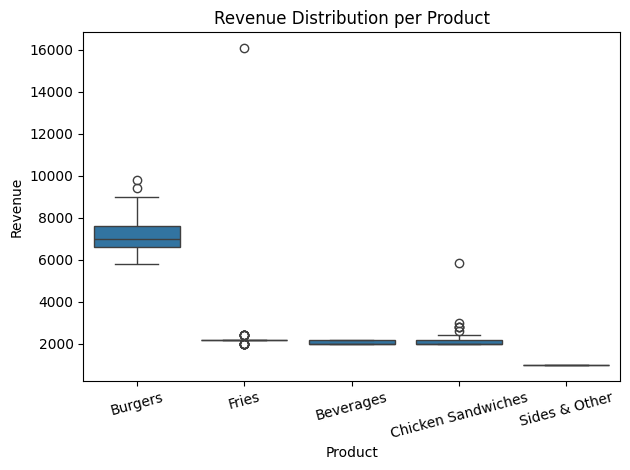

In [ ]:
# Boxplot: Revenue per Product — spot outliers per category
sns.boxplot(x='Product', y='Revenue', data=data,
            order=data.groupby('Product')['Revenue'].median().sort_values(ascending=False).index)
plt.title("Revenue Distribution per Product")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

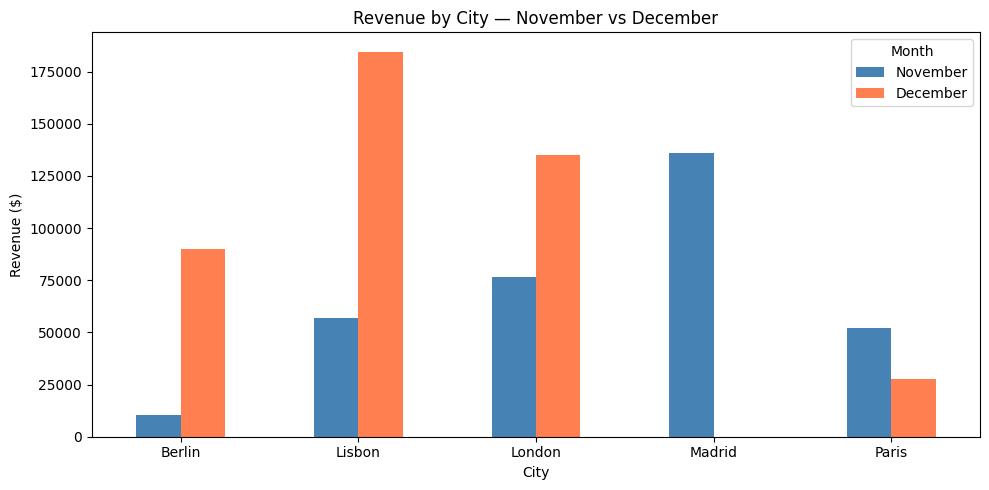

In [ ]:
# Revenue per City per Month — grouped bar
pivot = data.groupby(['City', 'Month'])['Revenue'].sum().unstack()
pivot.columns = ['November', 'December']
pivot.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'])
plt.title("Revenue by City — November vs December")
plt.xlabel("City")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=0)
plt.legend(title='Month')
plt.tight_layout()
plt.show()

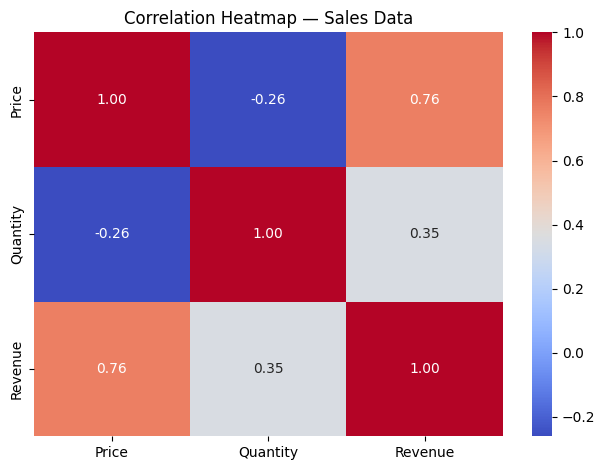

In [ ]:
# Correlation heatmap
sns.heatmap(data[['Price', 'Quantity', 'Revenue']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap — Sales Data")
plt.tight_layout()
plt.show()

## 8. Key Insights

After analyzing **254 sales transactions across 5 European cities (Nov–Dec 2022)**:

1. **Cash is the most preferred payment method**  
   Despite digital alternatives, cash dominates transactions — relevant for operational planning around cash handling.

2. **Burgers lead in revenue, Beverages lead in quantity**  
   This separation reveals an important insight: volume ≠ revenue. High-margin products like Burgers generate more money despite fewer units sold.

3. **Manager data had 14 "unique" values due to extra spaces — actually only 5 managers**  
   This is a real-world data quality trap. Without `str.strip().str.replace()`, every groupby analysis on Manager would be completely wrong.

4. **Revenue was higher in December than November**  
   The monthly comparison shows a clear increase — consistent with holiday season spending behavior.

5. **Revenue standard deviation is high relative to the mean**  
   With a mean of ~$3,030 and std of ~$2,420, the data is highly variable — some transactions are much larger than others, likely bulk or catering orders.

6. **Paris shows the highest revenue among all cities**  
   The city-wise analysis confirms Paris leads, suggesting either higher pricing, higher volume, or a combination of both.
